In [23]:
from importlib import reload
import simulate_data as sim
reload(sim)
from gwas import gwas_linear, gwas_probit
from scipy.stats import norm
import numpy as np

n, d = 5_000, 200
d_cov = 10
k = 10
corr = 0.7
rho = 0.7
snr_s = 1
snr_y = 1
pi_s = 0.1
pi_y = 0.05
p_sel = 0.3
rng = np.random.default_rng(42)

h2_s_cond = snr_s/(snr_s +1)
h2_s_cov = 0.2
h2_y = snr_y/(snr_y +1)
h2_y_cov = 0.2

# LD matrix
R = sim.simulate_block_correlation_matrix(d, k, corr)
Sigma_W = np.eye(d_cov)

G = sim.simulate_design_matrix(n, R, intercept = False, rng = rng)
W = sim.simulate_design_matrix(n, Sigma_W, intercept = True, rng = rng)

alpha = sim.beta_s(d, R, pi_s, snr_s, rng)
gamma_s = sim.gamma_s(d_cov, Sigma_W, h2_s_cov, rng)

beta, non_genetic_noise_y = sim.beta_heckman(d, R, pi_y, snr_y, rng)
sigma2_y = non_genetic_noise_y - h2_y_cov
gamma_y = sim.gamma_s(d_cov, Sigma_W, h2_y_cov, rng)

s, y, s_star, y_star =  sim.heckman_outcome(G, W, alpha, beta, gamma_s, gamma_y, sigma2_y, p_sel, rho, h2_s_cond, rng)


z_s, b_s_raw = gwas_probit(G, s)[0:2] 
b_s_rescaled = b_s_raw * np.sqrt(1+snr_s) 
b_s = z_s / np.sqrt(len(s)) 
b_y = gwas_linear(G, y)[0] / np.sqrt(s.sum()) # we assume Var(y) = 1 

# correction

In [22]:
from scipy.stats import norm
import numpy as np

# --- Heckman-corrected prediction of marginal outcome effects b_y ---
def predict_b_y(R, alpha, beta, gamma_s, gamma_y, Sigma_W, sigma2_y, rho, p_sel):
    """Return (naive, uncentered, centered) predictions of Cov(G, y* | s=1)."""
    Ra, Rb = R @ alpha, R @ beta

    h2_s = alpha @ Ra                       # Var(G^T alpha)
    V_W = gamma_s @ Sigma_W @ gamma_s       # Var(W^T gamma_s), intercept excluded
    c = np.sqrt(1 - h2_s)
    tau2 = (1 + V_W) / (1 - h2_s)
    q = norm.ppf(p_sel)
    phi_q = norm.pdf(q)
    lam = phi_q / p_sel                     # inverse Mills ratio at q
    psi = q * phi_q / tau2

    kappa = (alpha @ Rb + gamma_s @ Sigma_W @ gamma_y) / c
    K = kappa + rho * np.sqrt(sigma2_y)

    # E[G y* | s=1]  (no centering)
    theta_unc = psi * K / (p_sel * c)
    # Cov(G, y* | s=1)  (centered; matches OLS with intercept)
    theta_cen = K * phi_q * (q + lam) / (tau2 * p_sel * c)

    return Rb, Rb - theta_unc * Ra, Rb - theta_cen * Ra


b_naive, b_pred_unc, b_pred_cen = predict_b_y(
    R, alpha, beta, gamma_s[1:], gamma_y[1:], Sigma_W, sigma2_y, rho, p_sel
)

# --- Comparison against observed GWAS effects (target = b_y) ---
def report(name, pred, target):
    corr = np.corrcoef(pred, target)[0, 1]
    slope = (pred @ target) / (pred @ pred)         # regression through origin
    rmse = np.sqrt(np.mean((pred - target) ** 2))
    print(f"{name:<22} corr={corr:.3f}  slope={slope:.3f}  RMSE={rmse:.4f}")

N_y = int(s.sum())
print(f"N_y = {N_y}, sampling noise sd ~ {1/np.sqrt(N_y):.4f}")
report("naive  R@beta", b_naive, b_y)
report("Heckman (uncentered)", b_pred_unc, b_y)
report("Heckman (centered)", b_pred_cen, b_y)

# Selection-bias component only: b_y - R@beta vs predicted correction
report("bias term (centered)", b_pred_cen - b_naive, b_y - b_naive)

# Oracle check without GWAS noise: empirical covariance among selected samples
sel = s == 1
Gs, ys = G[sel], y_star[sel]
b_emp = (Gs - Gs.mean(0)).T @ (ys - ys.mean()) / N_y
report("naive vs empirical Cov", b_naive, b_emp)
report("Heckman centered vs emp", b_pred_cen, b_emp)

N_y = 30094, sampling noise sd ~ 0.0058
naive  R@beta          corr=0.974  slope=1.078  RMSE=0.0307
Heckman (uncentered)   corr=0.912  slope=0.989  RMSE=0.0519
Heckman (centered)     corr=0.998  slope=1.078  RMSE=0.0114
bias term (centered)   corr=0.927  slope=1.069  RMSE=0.0114
naive vs empirical Cov corr=0.972  slope=1.014  RMSE=0.0285
Heckman centered vs emp corr=0.999  slope=1.016  RMSE=0.0059


# Variance $y^*$ compared to the variance of $y^*\mid s_i =1$

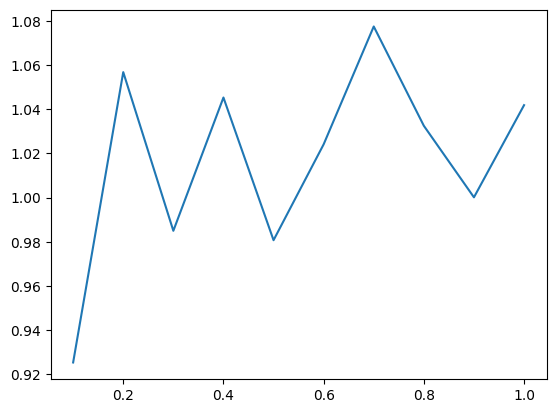

In [29]:
import matplotlib.pyplot as plt

n, d = 10_000, 200
d_cov = 10
k = 10
corr = 0.7
rho = 0.7
snr_s = 2
snr_y = 1
pi_s = 0.1
pi_y = 0.05
p_sel = 0.3
rng = np.random.default_rng(42)

h2_s_cond = snr_s/(snr_s +1)
h2_s_cov = 0.2
h2_y = snr_y/(snr_y +1)
h2_y_cov = 0.2

observed_var = []
p_sel_list = [(i+1)/10 for i in range(10)]


for p_sel in p_sel_list:
    # LD matrix
    R = sim.simulate_block_correlation_matrix(d, k, corr)
    Sigma_W = np.eye(d_cov)
    
    G = sim.simulate_design_matrix(n, R, intercept = False, rng = rng)
    W = sim.simulate_design_matrix(n, Sigma_W, intercept = True, rng = rng)
    
    alpha = sim.beta_s(d, R, pi_s, snr_s, rng)
    gamma_s = sim.gamma_s(d_cov, Sigma_W, h2_s_cov, rng)
    
    beta, non_genetic_noise_y = sim.beta_heckman(d, R, pi_y, snr_y, rng)
    sigma2_y = non_genetic_noise_y - h2_y_cov
    gamma_y = sim.gamma_s(d_cov, Sigma_W, h2_y_cov, rng)
    
    s, y, s_star, y_star =  sim.heckman_outcome(G, W, alpha, beta, gamma_s, gamma_y, sigma2_y, p_sel, rho, h2_s_cond, rng)

    observed_var.append(np.var(y[s==1]))
    
    #print(f"Observed variance: {np.var(y[s==1])}")
    #print(f"Latent variance: {np.var(y_star)}")

plt.plot(p_sel_list, observed_var)

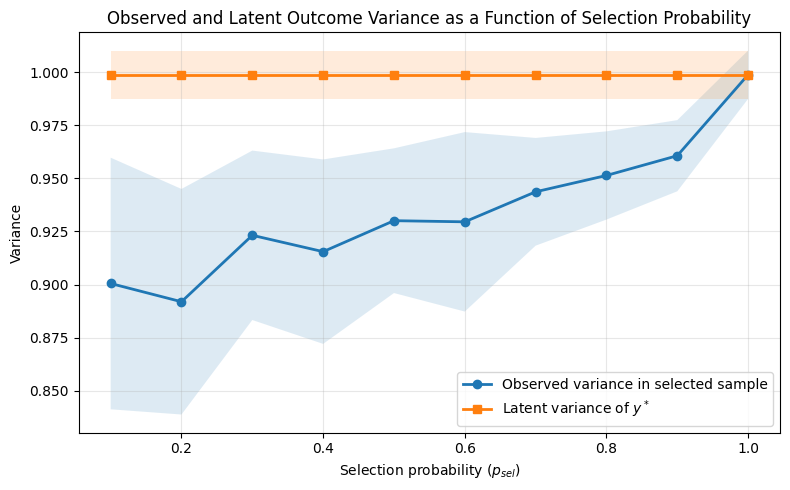

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from importlib import reload
reload(sim)

# Simulation parameters
n, d = 10_000, 200
d_cov = 10
k = 10
corr = 0.7

rho = 0.7
snr_s = 0.5
snr_y = 0.5
pi_s = 0.05
pi_y = 0.05

# Number of independent simulation seeds
n_seeds = 20

# Base seed for reproducibility
base_seed = 42

h2_s_cond = snr_s / (snr_s + 1)
h2_s_cov = 0.2
h2_y = snr_y / (snr_y + 1)
h2_y_cov = 0.2

p_sel_list = [(i + 1) / 10 for i in range(10)]

# Store mean and standard deviation of observed variance
mean_observed_var = []
sd_observed_var = []

# Store mean and standard deviation of latent variance
mean_latent_var = []
sd_latent_var = []


for p_sel_current in p_sel_list:

    observed_vars = []
    latent_vars = []

    for seed in range(base_seed, base_seed + n_seeds):

        rng = np.random.default_rng(seed)

        # LD matrix
        R = sim.simulate_block_correlation_matrix(
            d, k, corr
        )

        Sigma_W = np.eye(d_cov)

        # Genotypes
        G = sim.simulate_design_matrix(
            n,
            R,
            intercept=False,
            rng=rng
        )

        # Covariates
        W = sim.simulate_design_matrix(
            n,
            Sigma_W,
            intercept=True,
            rng=rng
        )

        # Selection effects
        alpha = sim.beta_s(
            d,
            R,
            pi_s,
            snr_s,
            rng
        )

        gamma_s = sim.gamma_s(
            d_cov,
            Sigma_W,
            h2_s_cov,
            rng
        )

        # Outcome genetic effects
        beta, non_genetic_noise_y = sim.beta_heckman(
            d,
            R,
            pi_y,
            snr_y,
            rng
        )

        sigma2_y = non_genetic_noise_y - h2_y_cov

        # Outcome covariate effects
        gamma_y = sim.gamma_y(
            d_cov,
            Sigma_W,
            h2_y_cov,
            rng=rng,
            intercept = True
        )

        # Simulate Heckman model
        s, y, s_star, y_star = sim.heckman_outcome(
            G,
            W,
            alpha,
            beta,
            gamma_s,
            gamma_y,
            sigma2_y,
            p_sel_current,
            rho,
            h2_s_cond,
            rng
        )

        # ---------------------------------------------------------
        # 1. Observed variance in the selected sample
        # ---------------------------------------------------------
        observed_vars.append(
            np.var(y[s == 1])
        )

        # ---------------------------------------------------------
        # 2. Latent variance in the full population
        # ---------------------------------------------------------
        latent_vars.append(
            np.var(y_star)
        )

    # -------------------------------------------------------------
    # Average across seeds
    # -------------------------------------------------------------
    mean_observed_var.append(
        np.mean(observed_vars)
    )

    sd_observed_var.append(
        np.std(observed_vars, ddof=1)
    )

    mean_latent_var.append(
        np.mean(latent_vars)
    )

    sd_latent_var.append(
        np.std(latent_vars, ddof=1)
    )


# Convert to arrays
mean_observed_var = np.asarray(mean_observed_var)
sd_observed_var = np.asarray(sd_observed_var)

mean_latent_var = np.asarray(mean_latent_var)
sd_latent_var = np.asarray(sd_latent_var)


# ================================================================
# Plot
# ================================================================

plt.figure(figsize=(8, 5))

# Observed variance among selected individuals
plt.plot(
    p_sel_list,
    mean_observed_var,
    marker="o",
    linewidth=2,
    label="Observed variance in selected sample"
)

# Latent variance in the full population
plt.plot(
    p_sel_list,
    mean_latent_var,
    marker="s",
    linewidth=2,
    label="Latent variance of $y^*$"
)

# Optional: ±1 SD for observed variance
plt.fill_between(
    p_sel_list,
    mean_observed_var - sd_observed_var,
    mean_observed_var + sd_observed_var,
    alpha=0.15
)

# Optional: ±1 SD for latent variance
plt.fill_between(
    p_sel_list,
    mean_latent_var - sd_latent_var,
    mean_latent_var + sd_latent_var,
    alpha=0.15
)

plt.xlabel("Selection probability ($p_{sel}$)")
plt.ylabel("Variance")
plt.title(
    "Observed and Latent Outcome Variance "
    "as a Function of Selection Probability"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

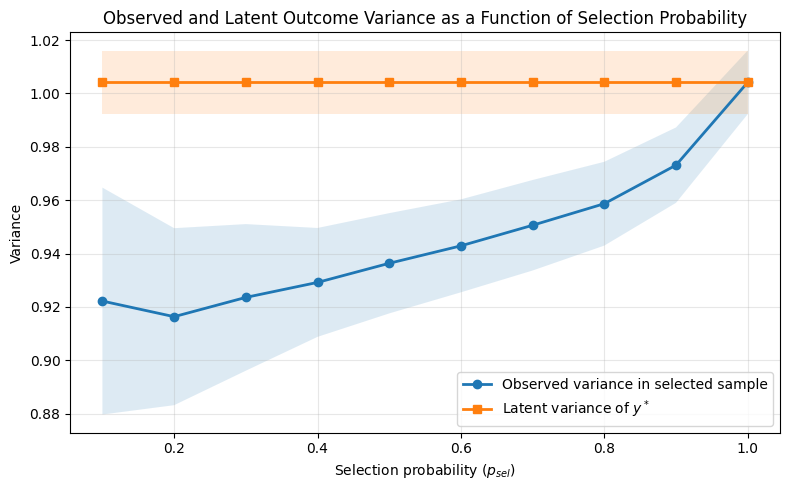

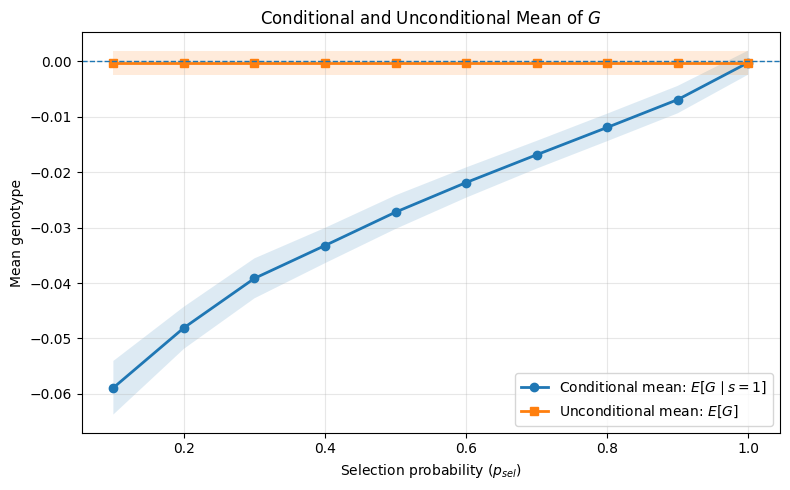

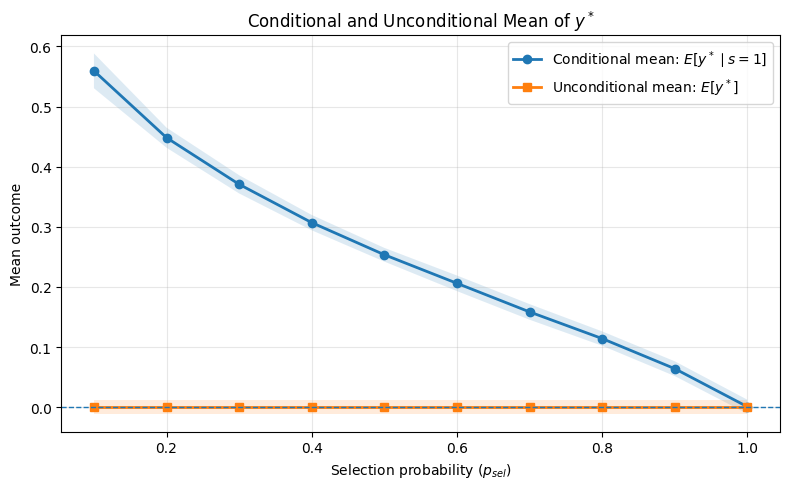

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from importlib import reload

reload(sim)


# ================================================================
# Simulation parameters
# ================================================================

n, d = 10_000, 200
d_cov = 10
k = 10
corr = 0.7

rho = 0.7
snr_s = 0.5
snr_y = 0.5
pi_s = 0.05
pi_y = 0.05

# Number of independent simulation seeds
n_seeds = 20

# Base seed for reproducibility
base_seed = 42

h2_s_cond = snr_s / (snr_s + 1)
h2_s_cov = 0.2

h2_y = snr_y / (snr_y + 1)
h2_y_cov = 0.2

p_sel_list = [(i + 1) / 10 for i in range(10)]


# ================================================================
# Storage: outcome variance
# ================================================================

mean_observed_var = []
sd_observed_var = []

mean_latent_var = []
sd_latent_var = []


# ================================================================
# Storage: conditional and unconditional mean of G
# ================================================================

mean_G_conditional = []
sd_G_conditional = []

mean_G_unconditional = []
sd_G_unconditional = []


# ================================================================
# Storage: conditional and unconditional mean of y
# ================================================================

mean_y_conditional = []
sd_y_conditional = []

mean_y_unconditional = []
sd_y_unconditional = []


# ================================================================
# Main simulation
# ================================================================



alpha = sim.beta_s(
    d,
    R,
    pi_s,
    snr_s,
    rng
)

gamma_s = sim.gamma_s(
    d_cov,
    Sigma_W,
    h2_s_cov,
    rng
)


# ========================================================
# Outcome genetic effects
# ========================================================

beta, non_genetic_noise_y = sim.beta_heckman(
    d,
    R,
    pi_y,
    snr_y,
    rng
)

sigma2_y = (
    non_genetic_noise_y
    - h2_y_cov
)


# ========================================================
# Outcome covariate effects
# ========================================================

gamma_y = sim.gamma_y(
    d_cov,
    Sigma_W,
    h2_y_cov,
    rng=rng,
    intercept=True
)

for p_sel_current in p_sel_list:

    # ------------------------------------------------------------
    # Outcome variance
    # ------------------------------------------------------------

    observed_vars = []
    latent_vars = []

    # ------------------------------------------------------------
    # G means
    # ------------------------------------------------------------

    G_conditional_means_seed = []
    G_unconditional_means_seed = []

    # ------------------------------------------------------------
    # y means
    # ------------------------------------------------------------

    y_conditional_means_seed = []
    y_unconditional_means_seed = []


    # ============================================================
    # Loop over seeds
    # ============================================================

    for seed in range(
        base_seed,
        base_seed + n_seeds
    ):

        rng = np.random.default_rng(seed)


        # ========================================================
        # LD matrix
        # ========================================================

        R = sim.simulate_block_correlation_matrix(
            d,
            k,
            corr
        )

        Sigma_W = np.eye(d_cov)


        # ========================================================
        # Genotypes
        # ========================================================

        G = sim.simulate_design_matrix(
            n,
            R,
            intercept=False,
            rng=rng
        )


        # ========================================================
        # Covariates
        # ========================================================

        W = sim.simulate_design_matrix(
            n,
            Sigma_W,
            intercept=True,
            rng=rng
        )



        # ========================================================
        # Simulate Heckman model
        # ========================================================

        s, y, s_star, y_star = sim.heckman_outcome(
            G,
            W,
            alpha,
            beta,
            gamma_s,
            gamma_y,
            sigma2_y,
            p_sel_current,
            rho,
            h2_s_cond,
            rng
        )


        # ========================================================
        # Selected sample
        # ========================================================

        selected = (s == 1)


        # ========================================================
        # 1. Observed variance
        # ========================================================

        observed_vars.append(
            np.var(y[selected])
        )


        # ========================================================
        # 2. Latent variance
        # ========================================================

        latent_vars.append(
            np.var(y_star)
        )


        # ========================================================
        # 3. Conditional mean of G
        #
        # First calculate mean of each SNP among selected
        # individuals:
        #
        #   E[G_j | s=1]
        #
        # Then average over SNPs:
        #
        #   mean_j E[G_j | s=1]
        # ========================================================

        G_selected = G[selected, :]

        G_mean_selected_by_snp = np.mean(
            G_selected,
            axis=0
        )

        G_conditional_means_seed.append(
            np.mean(
                G_mean_selected_by_snp
            )
        )


        # ========================================================
        # 4. Unconditional mean of G
        #
        # Same averaging over SNPs, but using the full sample.
        # ========================================================

        G_mean_by_snp = np.mean(
            G,
            axis=0
        )

        G_unconditional_means_seed.append(
            np.mean(
                G_mean_by_snp
            )
        )


        # ========================================================
        # 5. Conditional mean of y
        #
        # E[y* | s=1]
        # ========================================================

        y_selected = y_star[selected]

        y_conditional_means_seed.append(
            np.mean(
                y_selected
            )
        )


        # ========================================================
        # 6. Unconditional mean of y*
        #
        # E[y*]
        # ========================================================

        y_unconditional_means_seed.append(
            np.mean(
                y_star
            )
        )


    # =============================================================
    # Convert seed-level results to arrays
    # =============================================================

    observed_vars = np.asarray(
        observed_vars
    )

    latent_vars = np.asarray(
        latent_vars
    )

    G_conditional_means_seed = np.asarray(
        G_conditional_means_seed
    )

    G_unconditional_means_seed = np.asarray(
        G_unconditional_means_seed
    )

    y_conditional_means_seed = np.asarray(
        y_conditional_means_seed
    )

    y_unconditional_means_seed = np.asarray(
        y_unconditional_means_seed
    )


    # =============================================================
    # Outcome variance:
    # mean and SD across seeds
    # =============================================================

    mean_observed_var.append(
        np.mean(observed_vars)
    )

    sd_observed_var.append(
        np.std(
            observed_vars,
            ddof=1
        )
    )

    mean_latent_var.append(
        np.mean(latent_vars)
    )

    sd_latent_var.append(
        np.std(
            latent_vars,
            ddof=1
        )
    )


    # =============================================================
    # Conditional G mean:
    # mean and SD across seeds
    # =============================================================

    mean_G_conditional.append(
        np.mean(
            G_conditional_means_seed
        )
    )

    sd_G_conditional.append(
        np.std(
            G_conditional_means_seed,
            ddof=1
        )
    )


    # =============================================================
    # Unconditional G mean:
    # mean and SD across seeds
    # =============================================================

    mean_G_unconditional.append(
        np.mean(
            G_unconditional_means_seed
        )
    )

    sd_G_unconditional.append(
        np.std(
            G_unconditional_means_seed,
            ddof=1
        )
    )


    # =============================================================
    # Conditional y mean:
    # mean and SD across seeds
    # =============================================================

    mean_y_conditional.append(
        np.mean(
            y_conditional_means_seed
        )
    )

    sd_y_conditional.append(
        np.std(
            y_conditional_means_seed,
            ddof=1
        )
    )


    # =============================================================
    # Unconditional y mean:
    # mean and SD across seeds
    # =============================================================

    mean_y_unconditional.append(
        np.mean(
            y_unconditional_means_seed
        )
    )

    sd_y_unconditional.append(
        np.std(
            y_unconditional_means_seed,
            ddof=1
        )
    )


# ================================================================
# Convert everything to numpy arrays
# ================================================================

mean_observed_var = np.asarray(
    mean_observed_var
)

sd_observed_var = np.asarray(
    sd_observed_var
)

mean_latent_var = np.asarray(
    mean_latent_var
)

sd_latent_var = np.asarray(
    sd_latent_var
)

mean_G_conditional = np.asarray(
    mean_G_conditional
)

sd_G_conditional = np.asarray(
    sd_G_conditional
)

mean_G_unconditional = np.asarray(
    mean_G_unconditional
)

sd_G_unconditional = np.asarray(
    sd_G_unconditional
)

mean_y_conditional = np.asarray(
    mean_y_conditional
)

sd_y_conditional = np.asarray(
    sd_y_conditional
)

mean_y_unconditional = np.asarray(
    mean_y_unconditional
)

sd_y_unconditional = np.asarray(
    sd_y_unconditional
)


# ================================================================
# Plot 1:
# Observed vs latent outcome variance
# ================================================================

plt.figure(figsize=(8, 5))

plt.plot(
    p_sel_list,
    mean_observed_var,
    marker="o",
    linewidth=2,
    label="Observed variance in selected sample"
)

plt.plot(
    p_sel_list,
    mean_latent_var,
    marker="s",
    linewidth=2,
    label="Latent variance of $y^*$"
)

# ±1 SD
plt.fill_between(
    p_sel_list,
    mean_observed_var - sd_observed_var,
    mean_observed_var + sd_observed_var,
    alpha=0.15
)

plt.fill_between(
    p_sel_list,
    mean_latent_var - sd_latent_var,
    mean_latent_var + sd_latent_var,
    alpha=0.15
)

plt.xlabel(
    "Selection probability ($p_{sel}$)"
)

plt.ylabel(
    "Variance"
)

plt.title(
    "Observed and Latent Outcome Variance "
    "as a Function of Selection Probability"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ================================================================
# Plot 2:
# Conditional vs unconditional mean of G
# ================================================================

plt.figure(figsize=(8, 5))

# Conditional mean
plt.plot(
    p_sel_list,
    mean_G_conditional,
    marker="o",
    linewidth=2,
    label=r"Conditional mean: $E[G \mid s=1]$"
)

# Unconditional mean
plt.plot(
    p_sel_list,
    mean_G_unconditional,
    marker="s",
    linewidth=2,
    label=r"Unconditional mean: $E[G]$"
)

# ±1 SD: conditional
plt.fill_between(
    p_sel_list,
    mean_G_conditional - sd_G_conditional,
    mean_G_conditional + sd_G_conditional,
    alpha=0.15
)

# ±1 SD: unconditional
plt.fill_between(
    p_sel_list,
    mean_G_unconditional - sd_G_unconditional,
    mean_G_unconditional + sd_G_unconditional,
    alpha=0.15
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel(
    "Selection probability ($p_{sel}$)"
)

plt.ylabel(
    "Mean genotype"
)

plt.title(
    r"Conditional and Unconditional Mean of $G$"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ================================================================
# Plot 3:
# Conditional vs unconditional mean of y
# ================================================================

plt.figure(figsize=(8, 5))

# Conditional mean
plt.plot(
    p_sel_list,
    mean_y_conditional,
    marker="o",
    linewidth=2,
    label=r"Conditional mean: $E[y^* \mid s=1]$"
)

# Unconditional mean
plt.plot(
    p_sel_list,
    mean_y_unconditional,
    marker="s",
    linewidth=2,
    label=r"Unconditional mean: $E[y^*]$"
)

# ±1 SD: conditional
plt.fill_between(
    p_sel_list,
    mean_y_conditional - sd_y_conditional,
    mean_y_conditional + sd_y_conditional,
    alpha=0.15
)

# ±1 SD: unconditional
plt.fill_between(
    p_sel_list,
    mean_y_unconditional - sd_y_unconditional,
    mean_y_unconditional + sd_y_unconditional,
    alpha=0.15
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel(
    "Selection probability ($p_{sel}$)"
)

plt.ylabel(
    "Mean outcome"
)

plt.title(
    r"Conditional and Unconditional Mean of $y^*$"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

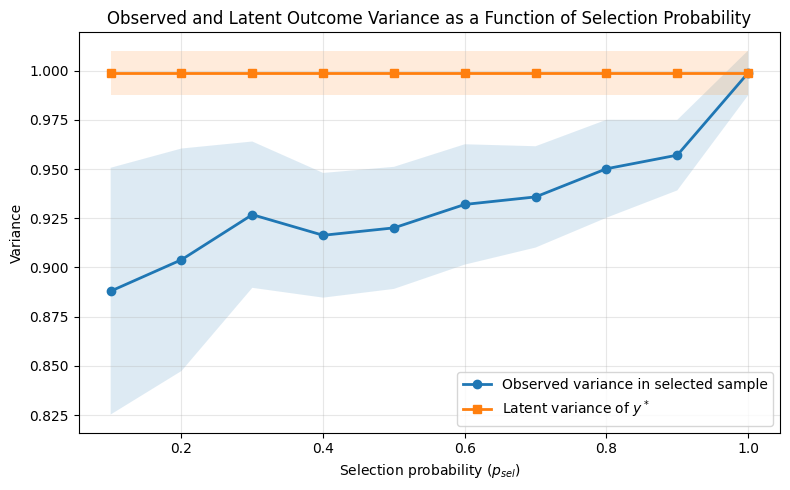

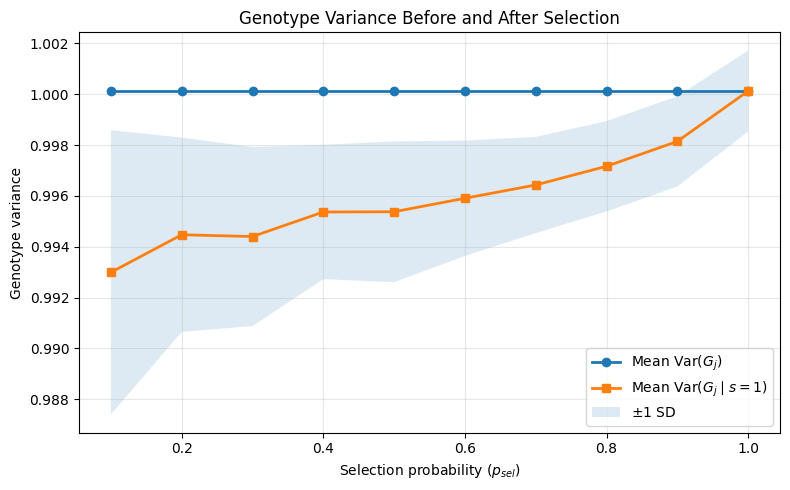

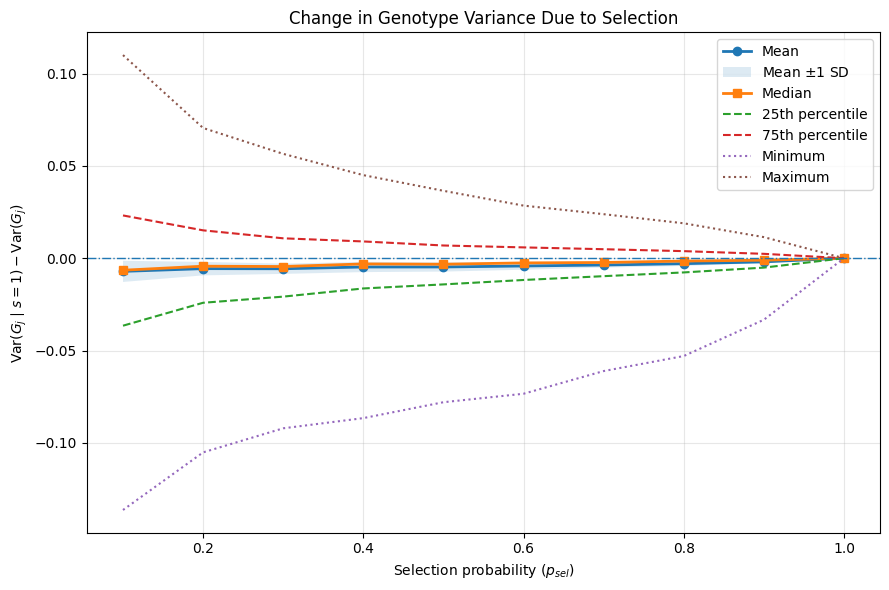

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from importlib import reload
reload(sim)

# ----------------------params-----------------------

n, d = 10_000, 200
d_cov = 10
k = 10
corr = 0.7

rho = 0.7
snr_s = 0.5
snr_y = 0.5
pi_s = 0.05
pi_y = 0.05

n_seeds = 20
base_seed = 42

h2_s_cond = snr_s / (snr_s + 1)
h2_s_cov = 0.2

h2_y = snr_y / (snr_y + 1)
h2_y_cov = 0.2

p_sel_list = [(i + 1) / 10 for i in range(10)]

# ----------------------storage-----------------------
mean_observed_var = []
sd_observed_var = []

mean_latent_var = []
sd_latent_var = []

mean_var_G = []
sd_var_G = []

mean_var_G_selected = []
sd_var_G_selected = []

mean_delta_by_seed = []
sd_delta_by_seed = []

min_delta_by_seed = []
q25_delta_by_seed = []
median_delta_by_seed = []
q75_delta_by_seed = []
max_delta_by_seed = []

# ----------------------simulation-----------------------

R = sim.simulate_block_correlation_matrix(
    d,
    k,
    corr
)

Sigma_W = np.eye(d_cov)

for p_sel_current in p_sel_list:

    observed_vars = []
    latent_vars = []

    var_G_by_seed = []
    var_G_selected_by_seed = []

    mean_delta_seed = []
    sd_delta_seed = []

    min_delta_seed = []
    q25_delta_seed = []
    median_delta_seed = []
    q75_delta_seed = []
    max_delta_seed = []

    for seed in range(base_seed, base_seed + n_seeds):

        rng = np.random.default_rng(seed)

        # ----------------------data generation-----------------------

        G = sim.simulate_design_matrix(
            n,
            R,
            intercept=False,
            rng=rng
        )

        W = sim.simulate_design_matrix(
            n,
            Sigma_W,
            intercept=True,
            rng=rng
        )

        alpha = sim.beta_s(
            d,
            R,
            pi_s,
            snr_s,
            rng
        )

        gamma_s = sim.gamma_s(
            d_cov,
            Sigma_W,
            h2_s_cov,
            rng
        )

        beta, non_genetic_noise_y = sim.beta_heckman(
            d,
            R,
            pi_y,
            snr_y,
            rng
        )

        sigma2_y = 1.0 - h2_y - h2_y_cov

        gamma_y = sim.gamma_y(
            d_cov,
            Sigma_W,
            h2_y_cov,
            rng=rng,
            intercept=True
        )

        s, y, s_star, y_star = sim.heckman_outcome(
            G,
            W,
            alpha,
            beta,
            gamma_s,
            gamma_y,
            sigma2_y,
            p_sel_current,
            rho,
            h2_s_cond,
            rng
        )


        # ========================================================
        # 1. Outcome variance
        # ========================================================

        observed_vars.append(
            np.var(y[s == 1])
        )

        latent_vars.append(
            np.var(y_star)
        )

        # ========================================================
        # 2. Genotype variance
        # ========================================================

        var_G = np.var(
            G,
            axis=0
        )

        var_G_selected = np.var(
            G[s == 1, :],
            axis=0
        )

        var_G_by_seed.append(
            np.mean(var_G)
        )

        var_G_selected_by_seed.append(
            np.mean(var_G_selected)
        )


        # ========================================================
        # 3. Change in genotype variance
        # ========================================================

        delta_var_G = (
            var_G_selected - var_G
        )

        mean_delta_seed.append(
            np.mean(delta_var_G)
        )

        sd_delta_seed.append(
            np.std(delta_var_G, ddof=1)
        )

        min_delta_seed.append(
            np.min(delta_var_G)
        )

        q25_delta_seed.append(
            np.percentile(delta_var_G, 25)
        )

        median_delta_seed.append(
            np.percentile(delta_var_G, 50)
        )

        q75_delta_seed.append(
            np.percentile(delta_var_G, 75)
        )

        max_delta_seed.append(
            np.max(delta_var_G)
        )


    # =============================================================
    # Outcome variance: aggregate across seeds
    # =============================================================

    mean_observed_var.append(
        np.mean(observed_vars)
    )

    sd_observed_var.append(
        np.std(observed_vars, ddof=1)
    )

    mean_latent_var.append(
        np.mean(latent_vars)
    )

    sd_latent_var.append(
        np.std(latent_vars, ddof=1)
    )


    # =============================================================
    # Genotype variance: aggregate across seeds
    # =============================================================

    mean_var_G.append(
        np.mean(var_G_by_seed)
    )

    sd_var_G.append(
        np.std(var_G_by_seed, ddof=1)
    )

    mean_var_G_selected.append(
        np.mean(var_G_selected_by_seed)
    )

    sd_var_G_selected.append(
        np.std(var_G_selected_by_seed, ddof=1)
    )


    # =============================================================
    # Change in genotype variance:
    #
    # First calculate statistic within each seed,
    # then average across seeds and calculate SD across seeds.
    # =============================================================

    mean_delta_by_seed.append(
        np.mean(mean_delta_seed)
    )

    sd_delta_by_seed.append(
        np.std(mean_delta_seed, ddof=1)
    )

    min_delta_by_seed.append(
        np.mean(min_delta_seed)
    )

    q25_delta_by_seed.append(
        np.mean(q25_delta_seed)
    )

    median_delta_by_seed.append(
        np.mean(median_delta_seed)
    )

    q75_delta_by_seed.append(
        np.mean(q75_delta_seed)
    )

    max_delta_by_seed.append(
        np.mean(max_delta_seed)
    )


# ================================================================
# Convert everything to numpy arrays
# ================================================================

mean_observed_var = np.asarray(mean_observed_var)
sd_observed_var = np.asarray(sd_observed_var)

mean_latent_var = np.asarray(mean_latent_var)
sd_latent_var = np.asarray(sd_latent_var)

mean_var_G = np.asarray(mean_var_G)
sd_var_G = np.asarray(sd_var_G)

mean_var_G_selected = np.asarray(mean_var_G_selected)
sd_var_G_selected = np.asarray(sd_var_G_selected)

mean_delta_by_seed = np.asarray(mean_delta_by_seed)
sd_delta_by_seed = np.asarray(sd_delta_by_seed)

min_delta_by_seed = np.asarray(min_delta_by_seed)
q25_delta_by_seed = np.asarray(q25_delta_by_seed)

median_delta_by_seed = np.asarray(
    median_delta_by_seed
)

q75_delta_by_seed = np.asarray(
    q75_delta_by_seed
)

max_delta_by_seed = np.asarray(
    max_delta_by_seed
)


# ================================================================
# Plot 1:
# Observed vs latent outcome variance
# ================================================================

plt.figure(figsize=(8, 5))

plt.plot(
    p_sel_list,
    mean_observed_var,
    marker="o",
    linewidth=2,
    label="Observed variance in selected sample"
)

plt.plot(
    p_sel_list,
    mean_latent_var,
    marker="s",
    linewidth=2,
    label="Latent variance of $y^*$"
)

# ±1 SD across seeds
plt.fill_between(
    p_sel_list,
    mean_observed_var - sd_observed_var,
    mean_observed_var + sd_observed_var,
    alpha=0.15
)

plt.fill_between(
    p_sel_list,
    mean_latent_var - sd_latent_var,
    mean_latent_var + sd_latent_var,
    alpha=0.15
)

plt.xlabel("Selection probability ($p_{sel}$)")
plt.ylabel("Variance")

plt.title(
    "Observed and Latent Outcome Variance "
    "as a Function of Selection Probability"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ================================================================
# Plot 2:
# Genotype variance before vs after selection
# ================================================================

plt.figure(figsize=(8, 5))

plt.plot(
    p_sel_list,
    mean_var_G,
    marker="o",
    linewidth=2,
    label=r"Mean $\mathrm{Var}(G_j)$"
)

plt.plot(
    p_sel_list,
    mean_var_G_selected,
    marker="s",
    linewidth=2,
    label=r"Mean $\mathrm{Var}(G_j \mid s=1)$"
)

# ±1 SD across seeds
plt.fill_between(
    p_sel_list,
    mean_var_G_selected - sd_var_G_selected,
    mean_var_G_selected + sd_var_G_selected,
    alpha=0.15,
    label=r"$\pm 1$ SD"
)

plt.xlabel("Selection probability ($p_{sel}$)")
plt.ylabel("Genotype variance")

plt.title(
    "Genotype Variance Before and After Selection"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ================================================================
# Plot 3:
# Change in genotype variance due to selection
#
# Statistics are first calculated within each seed across SNPs,
# then averaged across seeds.
#
# Shaded regions show ±1 SD ACROSS SEEDS for each statistic.
# ================================================================

plt.figure(figsize=(9, 6))

# ---------------------------------------------------------------
# Mean
# ---------------------------------------------------------------

plt.plot(
    p_sel_list,
    mean_delta_by_seed,
    marker="o",
    linewidth=2,
    label="Mean"
)

plt.fill_between(
    p_sel_list,
    mean_delta_by_seed - sd_delta_by_seed,
    mean_delta_by_seed + sd_delta_by_seed,
    alpha=0.15,
    label=r"Mean $\pm 1$ SD"
)


# ---------------------------------------------------------------
# Median
# ---------------------------------------------------------------

plt.plot(
    p_sel_list,
    median_delta_by_seed,
    marker="s",
    linewidth=2,
    label="Median"
)


# ---------------------------------------------------------------
# 25th percentile
# ---------------------------------------------------------------

plt.plot(
    p_sel_list,
    q25_delta_by_seed,
    linestyle="--",
    linewidth=1.5,
    label="25th percentile"
)


# ---------------------------------------------------------------
# 75th percentile
# ---------------------------------------------------------------

plt.plot(
    p_sel_list,
    q75_delta_by_seed,
    linestyle="--",
    linewidth=1.5,
    label="75th percentile"
)


# ---------------------------------------------------------------
# Minimum
# ---------------------------------------------------------------

plt.plot(
    p_sel_list,
    min_delta_by_seed,
    linestyle=":",
    linewidth=1.5,
    label="Minimum"
)


# ---------------------------------------------------------------
# Maximum
# ---------------------------------------------------------------

plt.plot(
    p_sel_list,
    max_delta_by_seed,
    linestyle=":",
    linewidth=1.5,
    label="Maximum"
)


# ---------------------------------------------------------------
# Reference line: no change
# ---------------------------------------------------------------

plt.axhline(
    0,
    linestyle="-.",
    linewidth=1
)


plt.xlabel("Selection probability ($p_{sel}$)")

plt.ylabel(
    r"$\mathrm{Var}(G_j \mid s=1) - \mathrm{Var}(G_j)$"
)

plt.title(
    "Change in Genotype Variance Due to Selection"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

h_s2 (alpha^T R alpha) = 0.333 | h2_s_cond = 0.333
V = 0.250, C = 0.100, z = -1.282, lambda = 1.755
Cov(s*, y*) = 0.619, kappa = -0.4112
Empirical selection rate: 0.100 (target p_sel = 0.1)


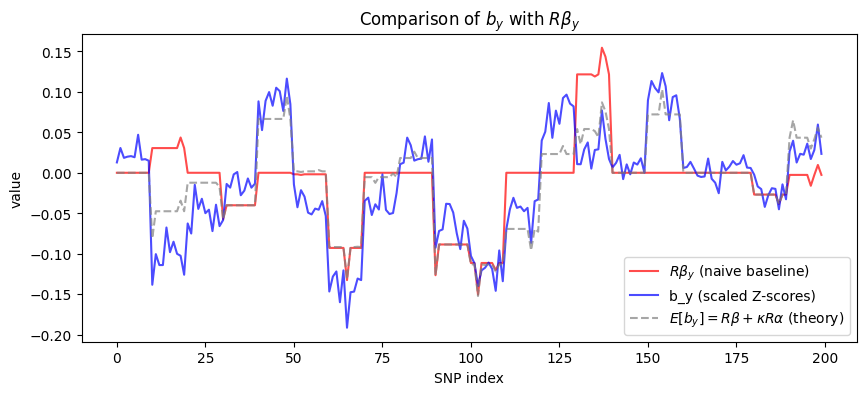

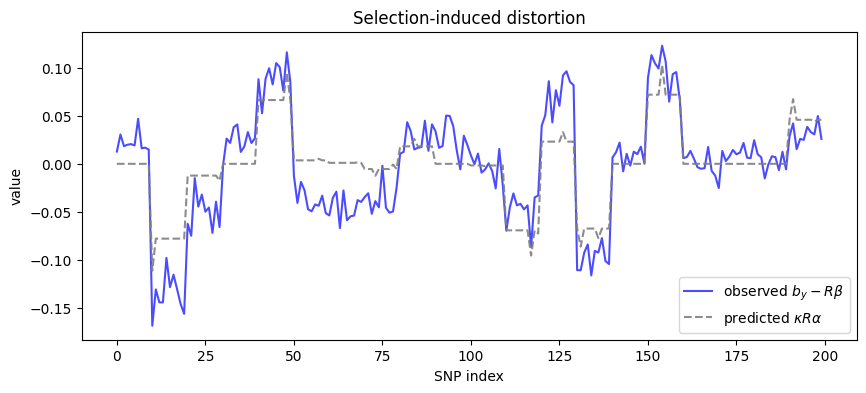

z_s
correlation: 0.992299420996823
slope: 72.46069074891541
RMSE: 6.939204334220531
b_s
correlation: 0.992299420996823
slope: 0.5123744579801943
RMSE: 0.047354724556643496
b_y (naive)
correlation: 0.5145127290725819
slope: 0.6756173261545113
RMSE: 0.058220156512350824
b_y_corrected
correlation: 0.8260890636672144
slope: 0.9106499746735824
RMSE: 0.031240458659126225


In [60]:
import matplotlib.pyplot as plt

from importlib import reload
import simulate_data as sim
reload(sim)
from gwas import gwas_linear, gwas_probit
from scipy.stats import norm
import numpy as np

n, d = 20_000, 200
d_cov = 10
k = 10
corr = 0.7
rho = 0.7
snr_s = 0.5
snr_y = 0.1
pi_s = 0.1
pi_y = 0.05
p_sel = 0.1
rng = np.random.default_rng(42)

h2_s_cond = snr_s/(snr_s +1)
h2_s_cov = 0.2
h2_y = snr_y/(snr_y +1)
h2_y_cov = 0.2

# LD matrix
R = sim.simulate_block_correlation_matrix(d, k, corr)
Sigma_W = np.eye(d_cov)

G = sim.simulate_design_matrix(n, R, intercept = False, rng = rng)
W = sim.simulate_design_matrix(n, Sigma_W, intercept = True, rng = rng)

alpha = sim.beta_s(d, R, pi_s, snr_s, rng)
gamma_s = sim.gamma_s(d_cov, Sigma_W, h2_s_cov, rng)

beta, non_genetic_noise_y = sim.beta_heckman(d, R, pi_y, snr_y, rng)
sigma2_y = non_genetic_noise_y - h2_y_cov
gamma_y = sim.gamma_s(d_cov, Sigma_W, h2_y_cov, rng)

s, y, s_star, y_star =  sim.heckman_outcome(G, W, alpha, beta, gamma_s, gamma_y, sigma2_y, p_sel, rho, h2_s_cond, rng)


z_s, b_s_raw = gwas_probit(G, s)[0:2] 
b_s_rescaled = b_s_raw * np.sqrt(1+snr_s) 
b_s = z_s / np.sqrt(len(s)) 
b_y = gwas_linear(G, y)[0] / np.sqrt(s.sum()) # we assume Var(y) = 1 

# --- Quantities needed for the closed-form kappa -------------------------
Ra = R @ alpha          # Cov(G, s*)
Rb = R @ beta           # naive baseline: marginal effect without selection

# Non-constant part of the covariate coefficients (intercept cancels out)
g_s = gamma_s[-d_cov:]
g_y = gamma_y[-d_cov:]

h_s2 = alpha @ R @ alpha            # genetic variance of s*
V = g_s @ Sigma_W @ g_s             # Var(W^T gamma_s)
C = g_y @ Sigma_W @ g_s             # gamma_y^T Sigma_W gamma_s
sigma_y = np.sqrt(sigma2_y)         # std of the y* noise independent of covariates

z = norm.ppf(p_sel)                 # z = Phi^{-1}(p)
lam = norm.pdf(z) / norm.cdf(z)     # inverse Mills ratio lambda(z)

# Cov(s*, y*) and the Pearson-Aitken kappa
cov_sy = alpha @ R @ beta + C + rho * sigma_y * np.sqrt(1 - h_s2)
kappa = -lam * (z + lam) / (1 + V) * cov_sy

print(f"h_s2 (alpha^T R alpha) = {h_s2:.3f} | h2_s_cond = {h2_s_cond:.3f}")
print(f"V = {V:.3f}, C = {C:.3f}, z = {z:.3f}, lambda = {lam:.3f}")
print(f"Cov(s*, y*) = {cov_sy:.3f}, kappa = {kappa:.4f}")
print(f"Empirical selection rate: {s.mean():.3f} (target p_sel = {p_sel})")

# --- Correction -----------------------------------------------------------
# E[b_y] = R beta + kappa * R alpha  =>  subtract the distortion
b_y_expected = Rb + kappa * Ra
b_y_corrected = b_y - kappa * Ra

# --- Plot: b_y ------------------------------------------------------------
plt.figure(figsize=(10, 4))
plt.plot(Rb, color="red", alpha=0.7, label=r"$R \beta_y$ (naive baseline)")
plt.plot(b_y, color="blue", alpha=0.7, label="b_y (scaled Z-scores)")
plt.plot(b_y_expected, color="grey", linestyle="--", alpha=0.7,
         label=r"$E[b_y] = R\beta + \kappa R\alpha$ (theory)")
plt.legend()
plt.xlabel("SNP index")
plt.ylabel("value")
plt.title(r"Comparison of $b_y$ with $R\beta_y$")
plt.show()

# --- Plot: distortion only ------------------------------------------------
plt.figure(figsize=(10, 4))
plt.plot(b_y - Rb, color="blue", alpha=0.7, label=r"observed $b_y - R\beta$")
plt.plot(kappa * Ra, color="grey", linestyle="--", alpha=0.9,
         label=r"predicted $\kappa R\alpha$")
plt.legend()
plt.xlabel("SNP index")
plt.ylabel("value")
plt.title("Selection-induced distortion")
plt.show()

# --- Statistics -----------------------------------------------------------
def report(name, x, target):
    print(name)
    print("correlation:", np.corrcoef(x, target)[0, 1])
    print("slope:", np.polyfit(target, x, 1)[0])  # should be ~1
    print("RMSE:", np.sqrt(np.mean((x - target) ** 2)))

report("z_s", z_s, Ra)
report("b_s", b_s, Ra)
report("b_y (naive)", b_y, Rb)
report("b_y_corrected", b_y_corrected, Rb)